In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re
import seaborn as sns
from matplotlib.ticker import MaxNLocator as ML
#Importing CSV files
path = '/Users/haleybrewster/Desktop/RHex_data'

Plotting RHex data from fluid tank. Payloads 0,1,2,3,4 kgs. x displacement(meters) versus time (seconds)

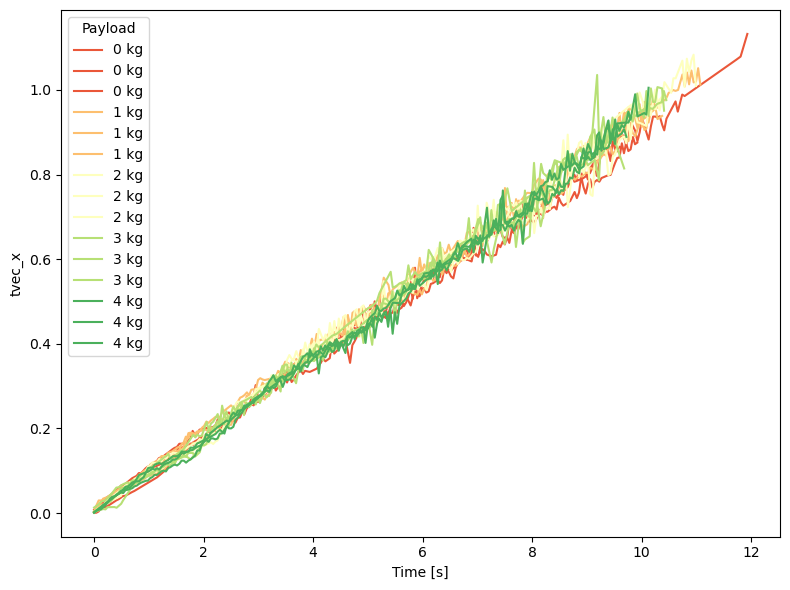

In [16]:
weights = [0, 1, 2, 3, 4]
colors = sns.color_palette("RdYlGn", n_colors=len(weights))

plt.figure(figsize=(8, 6))

for weight, color in zip(weights, colors):
    test_files = glob.glob(os.path.join(path,f"*water_{weight}kgs_t*_Marker33_Only.csv"))

    for trial_number, trial in enumerate(test_files):
        csv = pd.read_csv(trial)
        csv["tvec_x"] = pd.to_numeric(csv["tvec_x"])
        csv["Time [s]"]=pd.to_numeric(csv["Time (s)"])
        positive_x = csv["tvec_x"]>0
        csv_plot = csv[positive_x].copy()
        # to shift all plots to have an origin of t = 0
        

        first_positive_index = positive_x.idxmax()
        time_shift = csv.loc[first_positive_index, "Time (s)"]

        csv["Time (s)"] = csv["Time (s)"] - time_shift
        
        # add a column for starting at positive x values
        sns.lineplot(data=csv_plot,x=csv["Time (s)"],y=csv_plot["tvec_x"],color=color,label=f"{weight} kg")

plt.xlabel("Time [s]")
plt.ylabel("tvec_x")
plt.legend(title="Payload")
plt.tight_layout()
plt.show()

In [3]:
#print(x2)

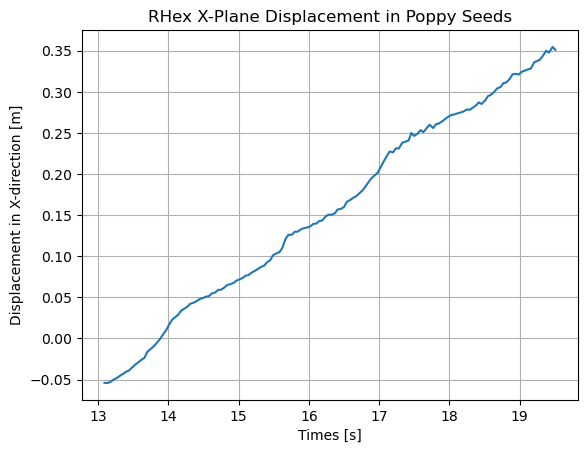

In [7]:
sns.lineplot(x=x1,y=y1)
#sns.lineplot(x=x2,y=y2)
plt.ylabel("Displacement in X-direction [m]")
plt.xlabel("Times [s]")
plt.grid(True)
plt.title("RHex X-Plane Displacement in Poppy Seeds");